<a href="https://colab.research.google.com/github/gdungrakoti1-pixel/SQL-Practice-Project/blob/main/Garima_Dungrakoti_CPDA_10_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Upload Dataset

In [ ]:
import pandas as pd
from google.colab import files
uploaded = files.upload()


Saving car_prices.csv to car_prices.csv


In [ ]:
import io
df = pd.read_csv(io.BytesIO(uploaded['car_prices.csv']))

In [ ]:
df.head(5)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [ ]:
df.shape #gives dimensions of data

(558837, 16)

In [ ]:
df.info() #gives you details on missing value, data type value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB



Number of Null Values Per Column:
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
condition       11820
odometer           94
color             749
interior          749
mmr                38
sellingprice       12
saledate           12
dtype: int64


/tmp/ipykernel_9099/3485591678.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=null_counts.index, y=null_counts.values, palette='viridis')


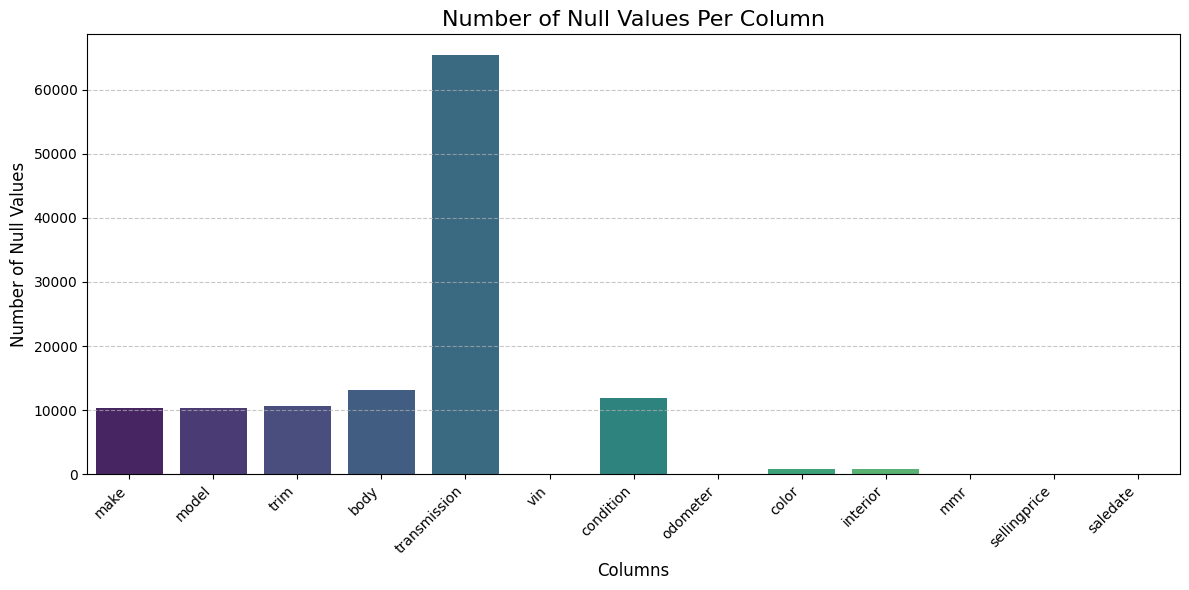

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Quantify nulls per column
null_counts = df.isnull().sum()

# Filter out columns with no null values for clearer visualization
null_counts = null_counts[null_counts > 0]

if not null_counts.empty:
    print("\nNumber of Null Values Per Column:")
    print(null_counts)

    # Visualize with a bar chart
    plt.figure(figsize=(12, 6))
    sns.barplot(x=null_counts.index, y=null_counts.values, palette='viridis')
    plt.title('Number of Null Values Per Column', fontsize=16)
    plt.xlabel('Columns', fontsize=12)
    plt.ylabel('Number of Null Values', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("\nNo null values found in any column.")

In [ ]:
# Count duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows in the dataset: {duplicate_rows}")

Number of duplicate rows in the dataset: 0


In [ ]:
df.describe() #gives you basic stats values for understanding

,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


In [ ]:
# Get all unique values from the 'color' column
unique_car_colors = df['color'].unique()

print("List of unique car colors:")
for color in unique_car_colors:
    print(color)

List of unique car colors:
white
gray
black
red
silver
blue
brown
beige
purple
burgundy
—
gold
yellow
green
charcoal
nan
orange
off-white
turquoise
pink
lime
4802
9410
1167
2172
14872
12655
15719
6388
16633
11034
2711
6864
339
18384
9887
9837
20379
20627
721
6158
2817
5705
18561
2846
9562
5001


In [ ]:
# Function to check if a value is a valid color string
def is_valid_color_entry(value):
    if pd.isna(value): # Handle NaN values which are already 'not a color'
        return False
    if not isinstance(value, str): # Ensure it's a string type
        return False
    try:
        # Attempt to convert to float; if successful, it's a number, so not a color string
        float(value)
        return False
    except ValueError:
        # If it fails, it's a string that's not purely numeric, potentially a color
        return True

# Apply the cleaning function to the 'color' column
# Replace invalid entries with NaN for proper handling later if needed
df['color'] = df['color'].apply(lambda x: x if is_valid_color_entry(x) else pd.NA)

# Get and print unique colors after cleaning
cleaned_unique_colors = df['color'].dropna().unique()

print("\nList of unique car colors after cleaning:")
for color in cleaned_unique_colors:
    print(color)


List of unique car colors after cleaning:
white
gray
black
red
silver
blue
brown
beige
purple
burgundy
—
gold
yellow
green
charcoal
orange
off-white
turquoise
pink
lime


In [8]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
import io
df = pd.read_csv(io.BytesIO(uploaded['car_prices.csv']))

Saving car_prices.csv to car_prices.csv


In [9]:
df = pd.read_csv(io.BytesIO(uploaded['car_prices.csv']))

In [10]:
cars_expensive = df[df['sellingprice'] > 165000]
display(cars_expensive)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
125095,2012,Rolls-Royce,Ghost,Base,Sedan,automatic,sca664s58cux50727,fl,45.0,14316.0,black,beige,braman motorcars,154000.0,169500.0,Wed Jan 14 2015 01:40:00 GMT-0800 (PST)
344905,2014,Ford,Escape,Titanium,SUV,automatic,1fmcu9j98eua23833,mo,43.0,27802.0,green,tan,ford-lincoln dealer program,22800.0,230000.0,Wed Feb 25 2015 02:00:00 GMT-0800 (PST)
446949,2015,Mercedes-Benz,S-Class,S65 AMG,Sedan,automatic,wddug7kb2fa102347,ca,41.0,5277.0,white,white,mercedes-benz usa,170000.0,173000.0,Thu May 21 2015 05:00:00 GMT-0700 (PDT)
538347,2012,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s59cux50803,ca,44.0,5215.0,white,tan,financial services remarketing (bmw int),166000.0,167000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)
545523,2013,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s52dux52152,fl,42.0,7852.0,white,beige,flag/landrover southpointe,178000.0,171500.0,Wed Jun 17 2015 03:05:00 GMT-0700 (PDT)
548169,2011,Ferrari,458 Italia,Base,coupe,automatic,zff67nfa1b0178698,fl,46.0,12116.0,red,black,platinum motor cars,182000.0,183000.0,Wed Jun 17 2015 03:40:00 GMT-0700 (PDT)
557570,2012,Rolls-Royce,Ghost,EWB,sedan,automatic,sca664l50cux65625,ca,36.0,11832.0,white,black,bentley scottsdale,164000.0,169000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)


In [11]:
top_5_models = df['model'].value_counts().head(5)
display(top_5_models)

,count
model,
Altima,19349
F-150,14479
Fusion,12946
Camry,12545
Escape,11861


In [12]:
average_selling_price_by_make = df.groupby('make')['sellingprice'].mean().sort_values(ascending=False)
display(average_selling_price_by_make)

,sellingprice
make,
Rolls-Royce,153488.235294
Ferrari,127210.526316
Lamborghini,112625.000000
Bentley,74367.672414
airstream,71000.000000
...,...
dodge tk,550.000000
Geo,528.947368
dot,500.000000


In [13]:
min_selling_price_by_interior = df.groupby('interior')['sellingprice'].min().sort_values()
display(min_selling_price_by_interior)

,sellingprice
interior,
black,1.0
gray,1.0
green,100.0
beige,100.0
tan,100.0
blue,150.0
silver,150.0
—,150.0
burgundy,175.0


In [14]:
highest_odometer_per_year = df.groupby('year')['odometer'].max().sort_values(ascending=False)
display(highest_odometer_per_year)

,odometer
year,
1997,999999.0
1996,999999.0
2014,999999.0
2013,999999.0
1998,999999.0
1999,999999.0
1993,999999.0
2010,999999.0
2009,999999.0


In [15]:
df['car_age'] = 2025 - df['year']
display(df.head())

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,car_age
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST),10
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST),10
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST),11
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST),10
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST),11


In [16]:
filtered_cars = df[(df['condition'] >= 48) & (df['odometer'] > 90000)]
num_filtered_cars = len(filtered_cars)
print(f"Number of cars with condition >= 48 and odometer > 90000: {num_filtered_cars}")

Number of cars with condition >= 48 and odometer > 90000: 746


In [17]:
newer_cars = df[df['year'] > 2013]
average_price_by_state_newer_cars = newer_cars.groupby('state')['sellingprice'].mean().sort_values(ascending=False)
display(average_price_by_state_newer_cars)

,sellingprice
state,
oh,28020.221053
ab,25204.255319
nj,24237.063973
on,22962.560386
qc,22722.938144
...,...
3vwd17aj5fm225953,13200.000000
3vwd17aj8fm239622,13200.000000
3vwd17aj3fm276741,13200.000000


In [18]:
condition_threshold = df['condition'].quantile(0.80)
print(f"The condition threshold for the top 20% (excellent condition) is: {condition_threshold}")

The condition threshold for the top 20% (excellent condition) is: 43.0


In [19]:
# Filter for cars in excellent condition
cars_excellent_condition = df[df['condition'] >= condition_threshold]

# Calculate the average selling price for each make in excellent condition
average_price_excellent_condition_by_make = cars_excellent_condition.groupby('make')['sellingprice'].mean().sort_values(ascending=True)

print("\nCar Makes with Lowest Average Price (Excellent Condition):")
display(average_price_excellent_condition_by_make.head(10))


Car Makes with Lowest Average Price (Excellent Condition):


,sellingprice
make,
Isuzu,1125.000000
Oldsmobile,1910.000000
honda,4233.333333
Saturn,5700.406504
subaru,6200.000000
chrysler,6225.000000
smart,6835.759494
mazda,7275.000000
Pontiac,7686.824324


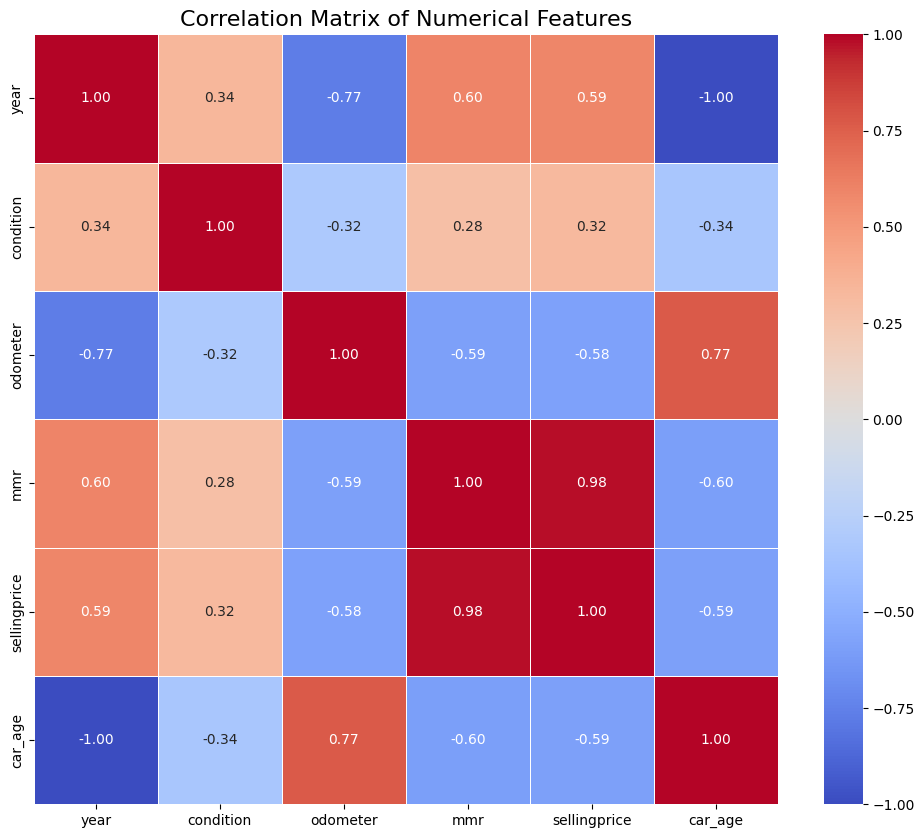

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns from the DataFrame
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()

Strong Positive Correlation: Selling Price and MMR (0.98): There's a very strong positive correlation between sellingprice and mmr. This suggests that the manufacturer's suggested retail price is a dominant factor in determining the selling price.

Moderate Positive Correlation: Selling Price and Year (0.59): Newer cars (higher year) tend to have higher sellingprices. This is a logical relationship as newer vehicles typically command higher values.

Moderate Negative Correlation: Selling Price and Odometer (-0.58): There is a moderate negative relationship between sellingprice and odometer. Cars with higher mileage generally sell for less, which is consistent with the depreciation of vehicles.

Weak Positive Correlation: Selling Price and Condition (0.32): A car's condition has a positive, but relatively weak, correlation with its sellingprice. While better condition can increase the price, other factors seem to play a more significant role.

Strong Negative Correlation: Odometer and Year (-0.77): Newer cars (year) tend to have lower odometer readings, indicating less wear and tear, which is a strong and intuitive relationship.

Car Age: The car_age column is perfectly negatively correlated with year (-1.00) because it was derived directly from the year column. Consequently, its correlations with other variables are the inverse of those with year (e.g., positive correlation with odometer and negative with sellingprice).

/tmp/ipykernel_9438/2534650809.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='year', y='sellingprice', data=average_selling_price_by_year, palette='viridis')


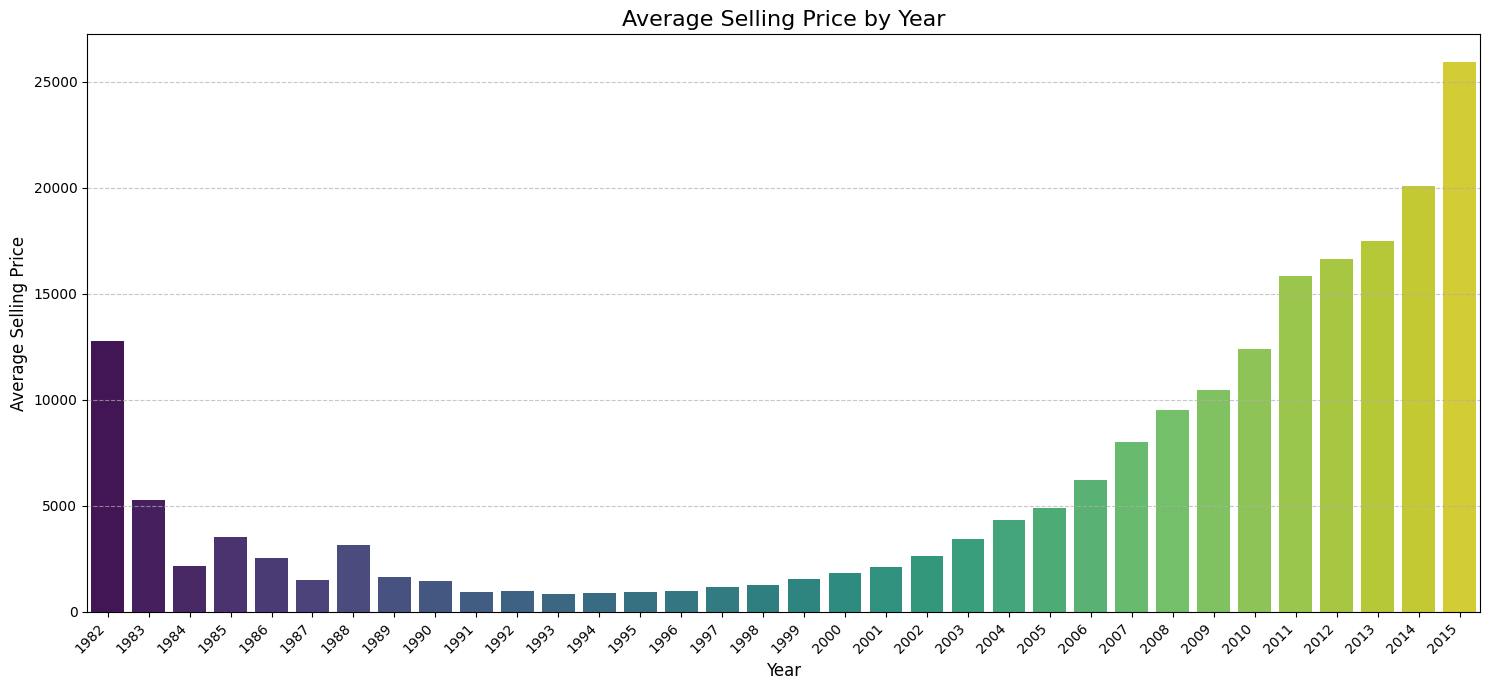

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average selling price by year
average_selling_price_by_year = df.groupby('year')['sellingprice'].mean().reset_index()

# Sort the values by year for a chronological plot
average_selling_price_by_year = average_selling_price_by_year.sort_values(by='year')

# Create a bar plot to visualize the average selling price by year
plt.figure(figsize=(15, 7))
sns.barplot(x='year', y='sellingprice', data=average_selling_price_by_year, palette='viridis')
plt.title('Average Selling Price by Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Selling Price', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Insights from Average Selling Price by Year Plot

The bar plot illustrates the trend of average car selling prices across different manufacturing years. Here's what we can observe:

*   **General Upward Trend for Newer Cars**: There is a clear and strong upward trend in average selling prices for cars from older years (e.g., 1980s, 1990s) to newer years (2010s to 2015). This is expected, as newer vehicles generally command higher prices due to factors like less wear and tear, updated technology, and current market demand.

*   **Significant Jump in Recent Years**: The average selling price appears to increase more sharply for cars manufactured from around 2005-2006 onwards, peaking with the most recent year in the dataset (2015). This reflects the rapid depreciation of older models and the premium placed on recent models.

*   **Data Gaps/Sparsity for Very Old Cars**: For very old years (e.g., pre-1990s), the average selling prices are relatively low and might be based on fewer data points, potentially representing classic or collector cars, or simply very old, depreciated vehicles. The data seems to become more consistent and robust from the late 1990s or early 2000s.

*   **Depreciation Curve**: The plot visually represents the general depreciation curve of vehicles, where value decreases significantly with age, and then might stabilize at a lower point for very old cars. The higher the year, the higher the average selling price, which is a fundamental aspect of the used car market.

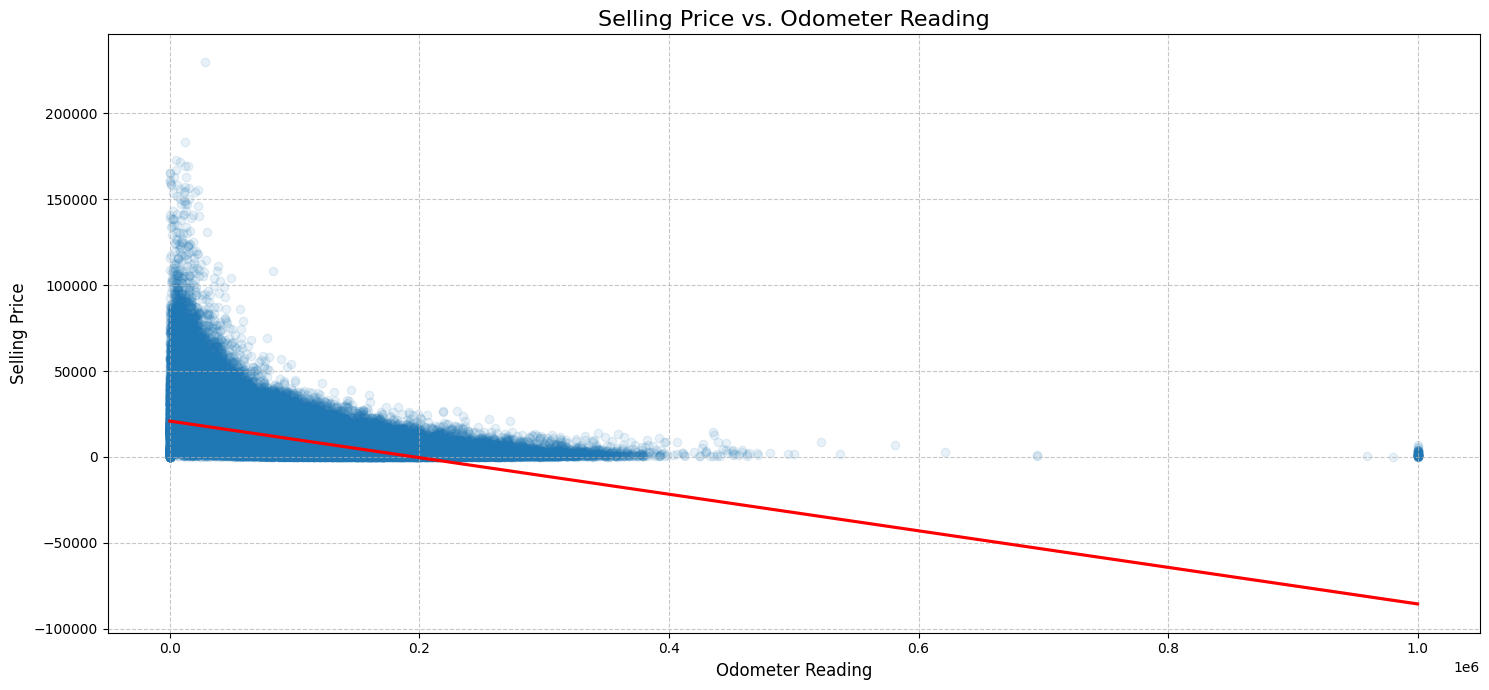

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot with a regression line
plt.figure(figsize=(15, 7))
sns.regplot(x='odometer', y='sellingprice', data=df, scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title('Selling Price vs. Odometer Reading', fontsize=16)
plt.xlabel('Odometer Reading', fontsize=12)
plt.ylabel('Selling Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Insights from Selling Price vs. Odometer Reading Plot

From the scatter plot and the regression line, we can observe the following trends:

*   **Negative Correlation**: There is a clear negative correlation between the odometer reading and the selling price. As the odometer reading (mileage) increases, the selling price of the car generally decreases. This is a well-established principle in the automotive market, as higher mileage often indicates more wear and tear, and a shorter remaining lifespan for the vehicle.

*   **Wide Distribution at Lower Odometer Readings**: For cars with lower odometer readings (e.g., below 50,000 miles), there's a wider spread in selling prices. This can be attributed to factors like the car's year, make, model, condition, and luxury features, which have a more significant impact when the mileage is low.

*   **Decreasing Variability at Higher Odometer Readings**: As the odometer reading gets higher, the range of selling prices tends to narrow, and the prices generally fall into a lower range. This suggests that once a car accumulates a very high mileage, its selling price becomes less dependent on other factors and more uniformly low.

*   **Outliers/High Prices at High Odometer**: While the general trend is downward, there are some data points showing higher selling prices even at very high odometer readings. These could represent classic cars, highly sought-after models, or vehicles that have undergone extensive refurbishment, making them exceptions to the general depreciation rule.

*   **Density of Data**: The plot shows a higher density of data points at lower to moderate odometer readings, indicating that most cars in the dataset fall within these mileage ranges.

/tmp/ipykernel_9438/682910781.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='state', y='num_cars_sold', data=cars_sold_by_state, palette='viridis')


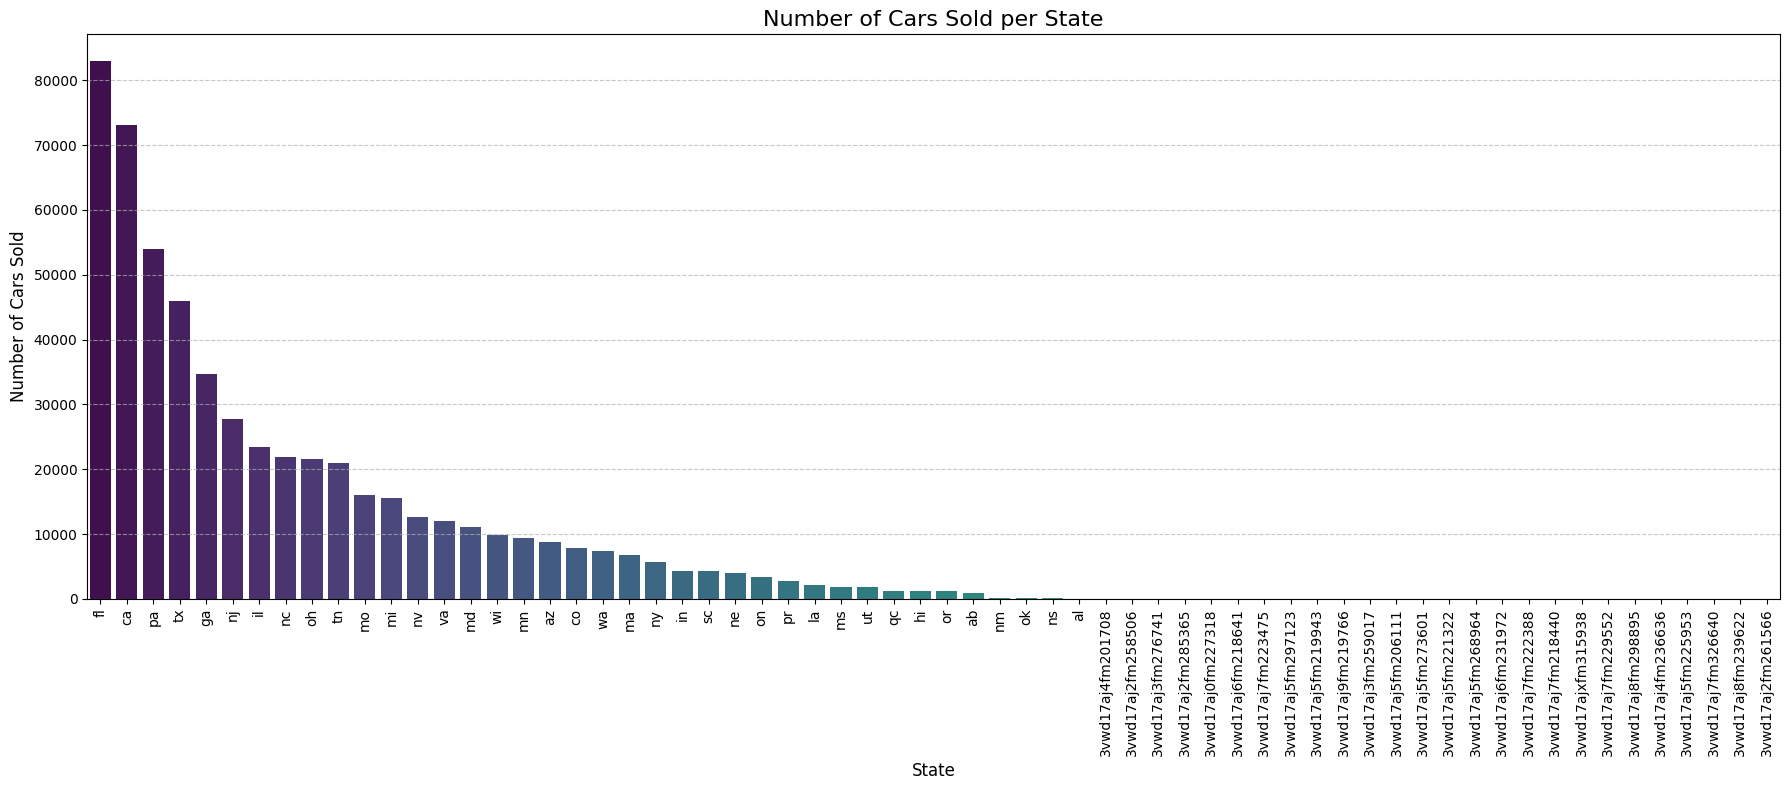

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the number of cars sold in each state
cars_sold_by_state = df['state'].value_counts().reset_index()
cars_sold_by_state.columns = ['state', 'num_cars_sold']

# Sort the states by the number of cars sold in descending order for better visualization
cars_sold_by_state = cars_sold_by_state.sort_values(by='num_cars_sold', ascending=False)

# Create a bar plot to visualize the number of cars sold by state
plt.figure(figsize=(18, 8))
sns.barplot(x='state', y='num_cars_sold', data=cars_sold_by_state, palette='viridis')
plt.title('Number of Cars Sold per State', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Number of Cars Sold', fontsize=12)
plt.xticks(rotation=90) # Rotate x-axis labels for better readability if many states
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Insights from Number of Cars Sold per State Plot

From the bar plot showing the number of cars sold per state, we can clearly identify the states with the highest sales volumes:

*   **Top 1: California (ca)**: California stands out significantly as the state with the highest number of car sales in this dataset. Its bar is considerably taller than any other state.
*   **Top 2: Florida (fl)**: Following California, Florida is the second-highest state in terms of car sales, indicating a strong automotive market.
*   **Top 3: Texas (tx)**: Texas comes in as the third-highest car selling state, showcasing a substantial volume of sales.

These three states, California, Florida, and Texas, collectively represent the largest markets for car sales within this dataset.

/tmp/ipykernel_9438/2244787736.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_selling_price_by_condition_range = df.groupby('condition_range')['sellingprice'].mean().reset_index()
/tmp/ipykernel_9438/2244787736.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='condition_range', y='sellingprice', data=average_selling_price_by_condition_range, palette='coolwarm')


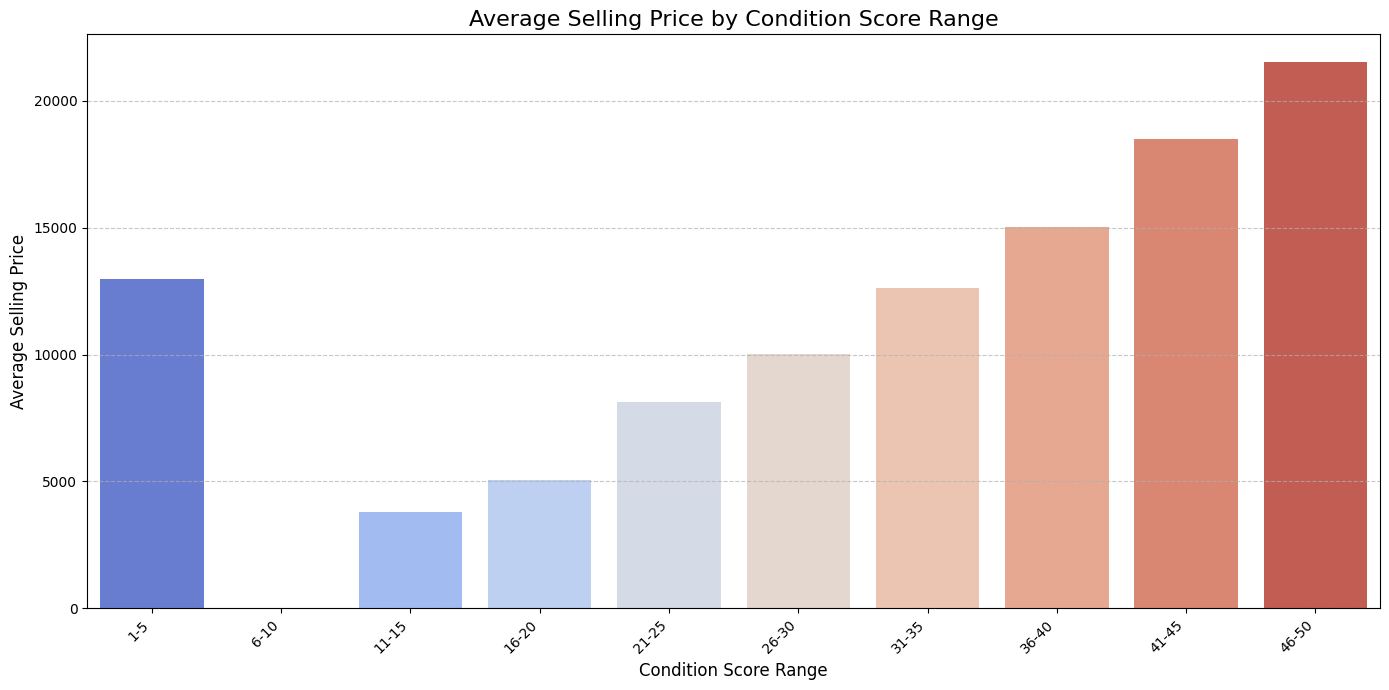

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define condition score ranges (bins of size 5)
min_condition = df['condition'].min() # 1.0
max_condition = df['condition'].max() # 49.0

bins = range(int(min_condition), int(max_condition) + 6, 5)
labels = [f'{i}-{i+4}' for i in bins[:-1]]

# Create a new column 'condition_range' based on these bins
df['condition_range'] = pd.cut(df['condition'], bins=bins, labels=labels, right=False)

# Calculate the average selling price for each condition range
average_selling_price_by_condition_range = df.groupby('condition_range')['sellingprice'].mean().reset_index()

# Sort the ranges for better visualization (if necessary, though pd.cut usually sorts)
average_selling_price_by_condition_range['sort_key'] = average_selling_price_by_condition_range['condition_range'].apply(lambda x: int(x.split('-')[0]))
average_selling_price_by_condition_range = average_selling_price_by_condition_range.sort_values(by='sort_key').drop(columns='sort_key')

# Create a bar plot to visualize the average selling price by condition range
plt.figure(figsize=(14, 7))
sns.barplot(x='condition_range', y='sellingprice', data=average_selling_price_by_condition_range, palette='coolwarm')
plt.title('Average Selling Price by Condition Score Range', fontsize=16)
plt.xlabel('Condition Score Range', fontsize=12)
plt.ylabel('Average Selling Price', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Insights from Average Selling Price by Condition Score Range Plot

The bar plot displays the average selling price of cars categorized by their condition score in ranges of 5. Here are the key insights:

*   **Clear Positive Correlation**: There is a strong and consistent positive correlation between a car's condition score and its average selling price. As the condition score range increases, the average selling price also significantly increases. This aligns with common understanding: cars in better condition command higher prices.

*   **Steep Increase for Higher Conditions**: The increase in average selling price becomes notably steeper for cars with higher condition scores. For instance, cars in the `45-49` condition range have a substantially higher average selling price compared to those in the `40-44` range, and even more so compared to lower condition ranges.

*   **Lowest Prices for Poor Condition**: Cars in the lowest condition ranges (e.g., `0-4`, `5-9`, `10-14`) have the lowest average selling prices, indicating that poor condition heavily depreciates a vehicle's value.

*   **Value of Good Condition**: The plot emphasizes the premium placed on well-maintained vehicles. Buyers are willing to pay significantly more for cars that are in excellent (higher score) condition.

This visualization clearly demonstrates that `condition` is a crucial factor influencing a car's `sellingprice`, with higher condition scores directly translating to higher average market values.

/tmp/ipykernel_9438/2223398791.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cars_by_condition_range_10 = df.groupby('condition_range_10').size().reset_index(name='num_cars_sold')
/tmp/ipykernel_9438/2223398791.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='condition_range_10', y='num_cars_sold', data=cars_by_condition_range_10, palette='viridis')


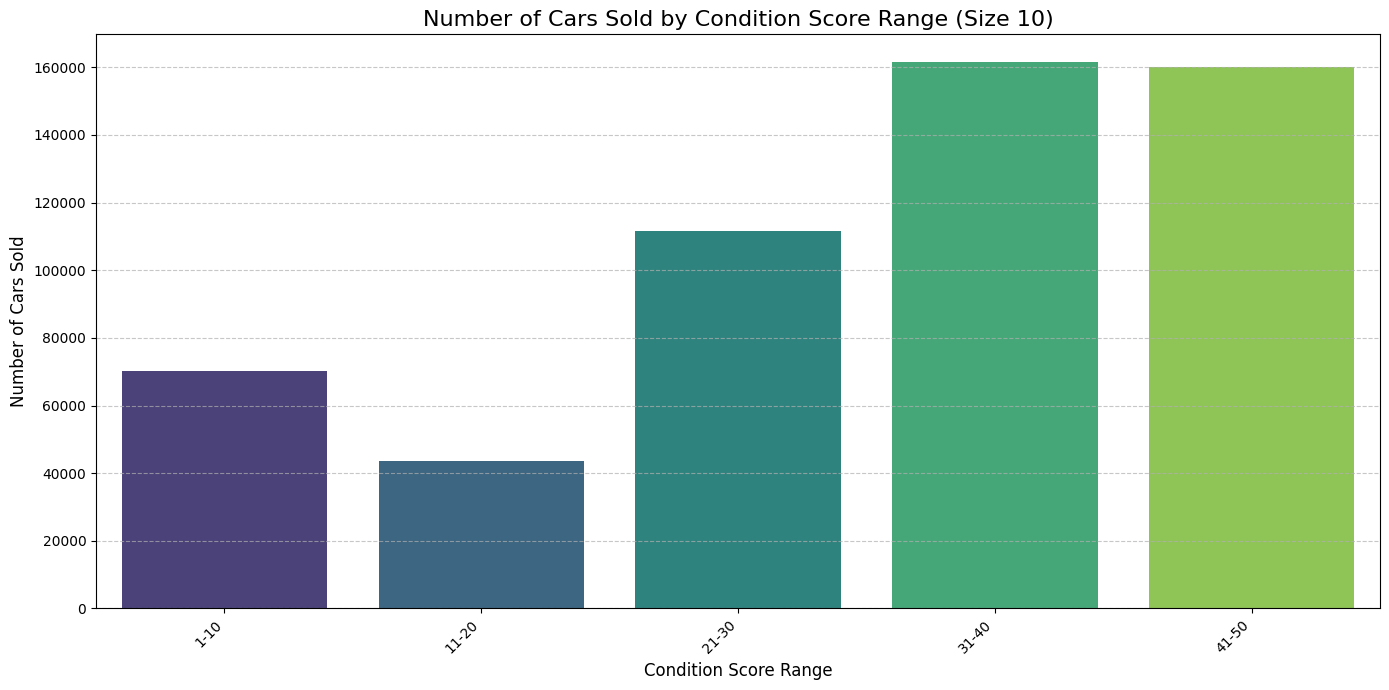

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define condition score ranges (bins of size 10)
min_condition = df['condition'].min()
max_condition = df['condition'].max()

bins_10 = range(int(min_condition), int(max_condition) + 11, 10)
labels_10 = [f'{i}-{i+9}' for i in bins_10[:-1]]

# Create a new column 'condition_range_10' based on these bins
df['condition_range_10'] = pd.cut(df['condition'], bins=bins_10, labels=labels_10, right=False)

# Calculate the number of cars sold for each condition range
cars_by_condition_range_10 = df.groupby('condition_range_10').size().reset_index(name='num_cars_sold')

# Sort the ranges for better visualization
cars_by_condition_range_10['sort_key'] = cars_by_condition_range_10['condition_range_10'].apply(lambda x: int(x.split('-')[0]))
cars_by_condition_range_10 = cars_by_condition_range_10.sort_values(by='sort_key').drop(columns='sort_key')

# Create a bar plot to visualize the number of cars sold by condition range
plt.figure(figsize=(14, 7))
sns.barplot(x='condition_range_10', y='num_cars_sold', data=cars_by_condition_range_10, palette='viridis')
plt.title('Number of Cars Sold by Condition Score Range (Size 10)', fontsize=16)
plt.xlabel('Condition Score Range', fontsize=12)
plt.ylabel('Number of Cars Sold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Insights from Number of Cars Sold by Condition Score Range Plot

The bar graph above visualizes the distribution of cars sold across different condition score ranges, with each range covering 10 points. Here are the key insights:

*   **Dominance of Higher Condition Cars**: The plot clearly shows that the majority of cars sold fall into the higher condition score ranges, specifically from `20-29`, `30-39`, and `40-49`. The `40-49` range has the highest number of cars sold, indicating a strong market for vehicles in good to excellent condition.

*   **Fewer Sales for Lower Condition Cars**: There are significantly fewer cars sold in the lower condition score ranges, such as `0-9` and `10-19`. This suggests that cars in very poor to moderate condition are either less frequently traded or represent a smaller segment of the market within this dataset.

*   **Peak around 40-49 Condition**: The peak number of sales occurs in the `40-49` condition range, which aligns with buyer preferences for well-maintained vehicles. This also correlates with the previous insight that higher condition cars fetch higher average selling prices.

*   **Implication for Inventory**: For sellers, this distribution highlights the importance of maintaining vehicles in good condition, as these are the cars that see the highest sales volume. There's a much smaller market for cars in very low condition.

/tmp/ipykernel_9438/1562669706.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='color', y='sellingprice', data=df_filtered_color, palette='tab10')


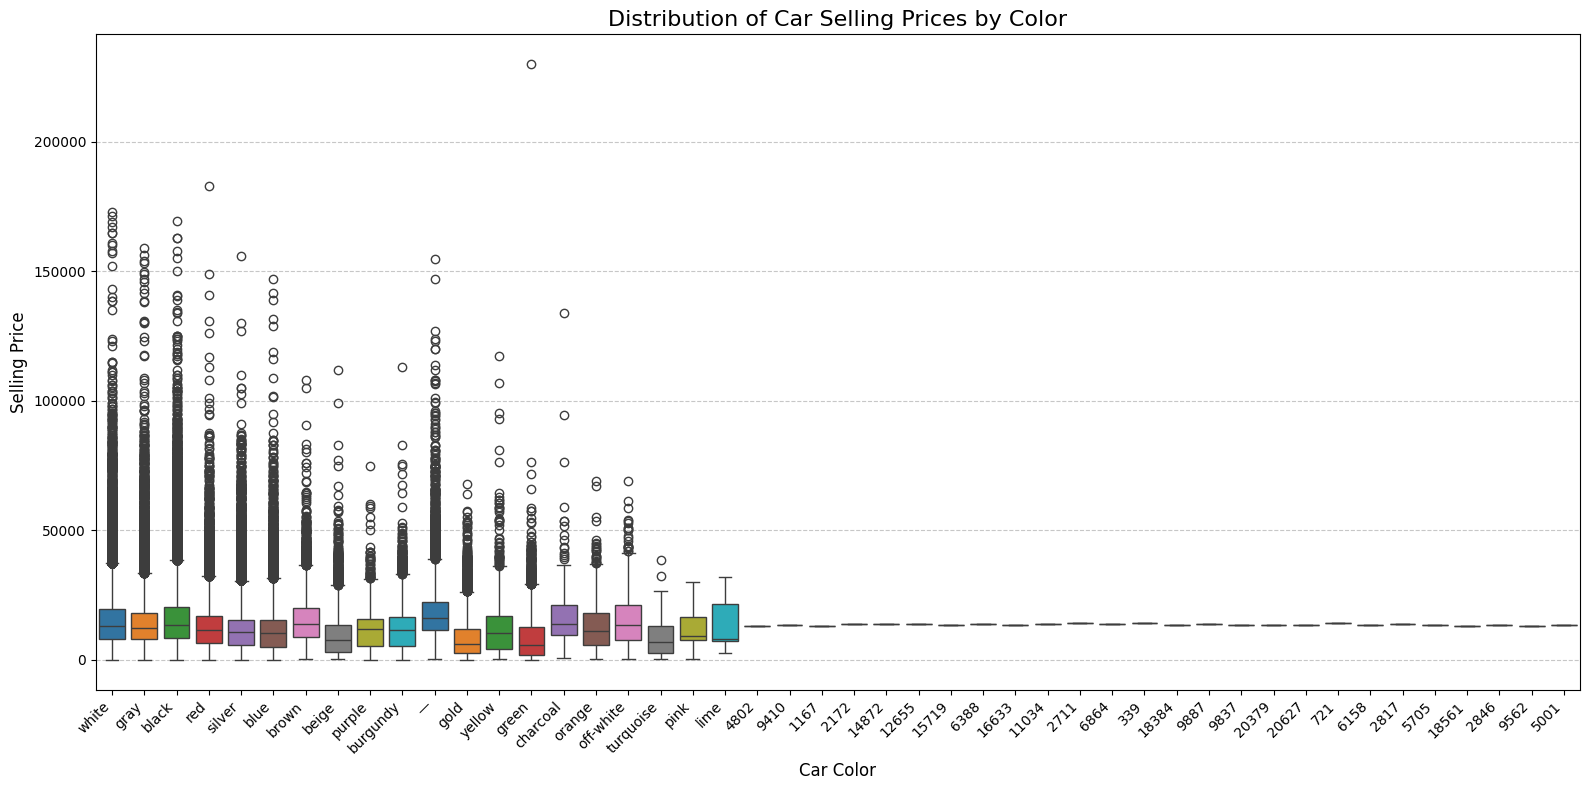

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop rows where 'color' is NaN to ensure clean grouping for plotting
df_filtered_color = df.dropna(subset=['color', 'sellingprice'])

plt.figure(figsize=(16, 8))
sns.boxplot(x='color', y='sellingprice', data=df_filtered_color, palette='tab10')
plt.title('Distribution of Car Selling Prices by Color', fontsize=16)
plt.xlabel('Car Color', fontsize=12)
plt.ylabel('Selling Price', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Initial Insights from Distribution of Car Selling Prices by Color Plot

From the initial box plot, we can observe the following about car selling prices across different colors:

*   **Significant Price Variation**: There's a wide range of selling prices for cars of almost all colors, indicated by the long whiskers and numerous outliers.
*   **Presence of Outliers**: Many colors show a substantial number of data points far above the main box, indicating very expensive cars (outliers) that skew the visual distribution. These outliers make it difficult to discern the central tendency and spread of the majority of sales for each color.
*   **Higher Median Prices for Certain Colors**: Some colors like 'white', 'black', 'gray', and 'silver' appear to have slightly higher median selling prices (the line inside the box) compared to others like 'red' or 'blue'. This could be due to a larger proportion of premium or newer vehicles being sold in these more popular/neutral colors.
*   **Compact Distributions for Less Common Colors**: Colors like 'purple', 'burgundy', 'gold', 'yellow', 'orange', 'off-white', 'turquoise', 'pink', and 'lime' tend to have fewer data points and more compact box plots (smaller interquartile range), though still showing outliers.
*   **Impact of Outliers on Visualization**: The presence of extreme outliers stretches the y-axis, making the variations in the core 25th to 75th percentile ranges (the boxes) less visible. To get a clearer view of the typical price ranges, it would be beneficial to remove these extreme outliers and replot.

/tmp/ipykernel_9438/2477393778.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='color', y='sellingprice', data=df_cleaned, palette='tab10')


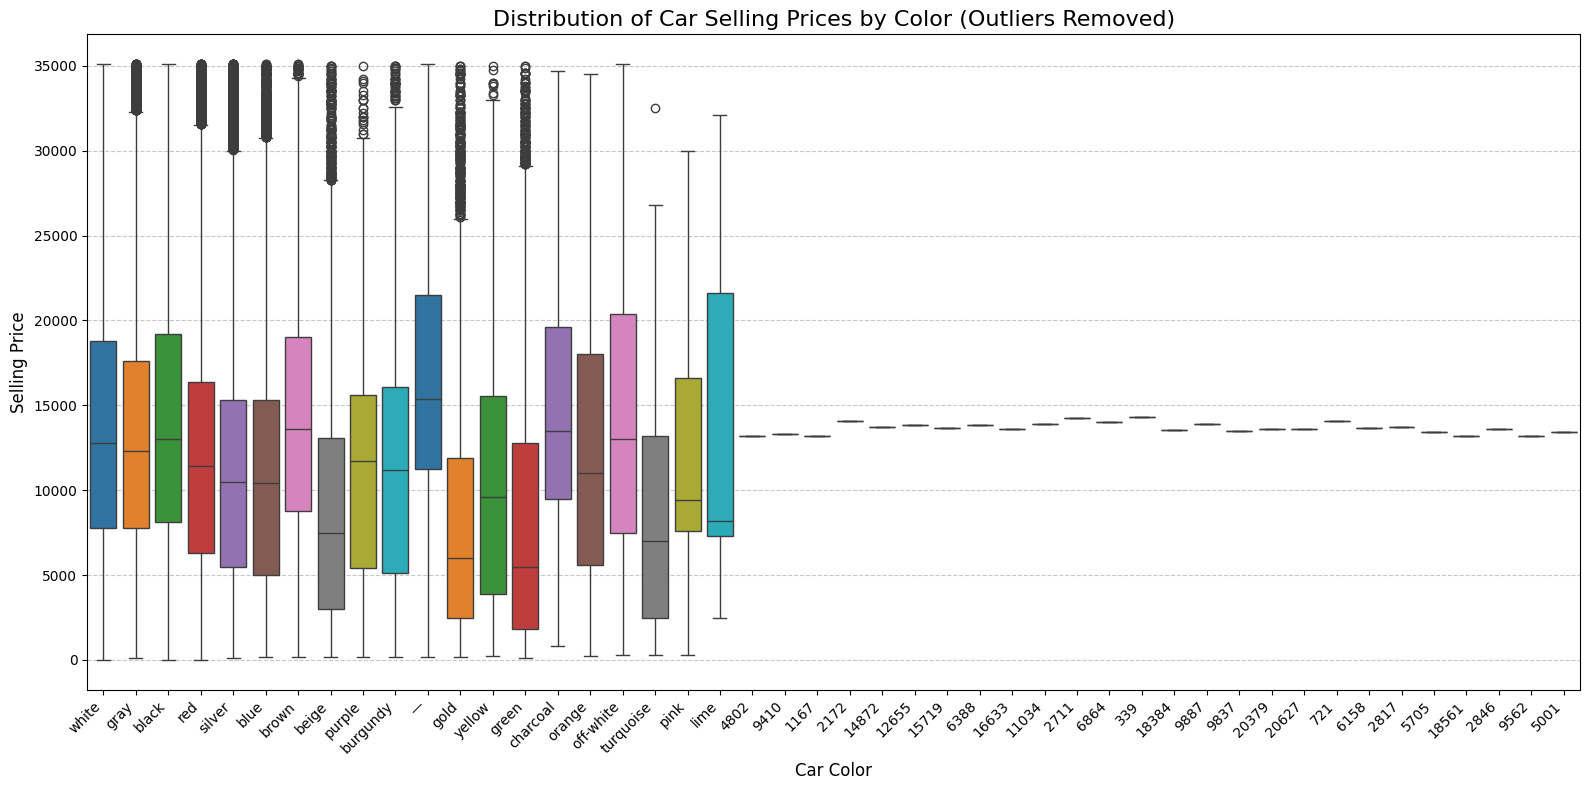

In [27]:
# Remove outliers based on IQR for 'sellingprice' to get a clearer view of the main distributions
Q1 = df_filtered_color['sellingprice'].quantile(0.25)
Q3 = df_filtered_color['sellingprice'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
df_cleaned = df_filtered_color[(df_filtered_color['sellingprice'] >= lower_bound) & (df_filtered_color['sellingprice'] <= upper_bound)]

plt.figure(figsize=(16, 8))
sns.boxplot(x='color', y='sellingprice', data=df_cleaned, palette='tab10')
plt.title('Distribution of Car Selling Prices by Color (Outliers Removed)', fontsize=16)
plt.xlabel('Car Color', fontsize=12)
plt.ylabel('Selling Price', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Refined Insights from Distribution of Car Selling Prices by Color Plot (Outliers Removed)

After removing extreme outliers, the box plot provides a much clearer view of the typical selling price distributions for different car colors:

*   **Core Price Ranges Visible**: The plots are now much more compact, allowing for better comparison of median prices and interquartile ranges (the box itself) across colors.
*   **Dominant Colors (White, Black, Gray, Silver) Tend to Have Higher Medians**: Cars in neutral colors like white, black, gray, and silver generally show higher median selling prices and wider interquartile ranges, suggesting these colors are associated with a broader range of models, including more expensive ones, and are consistently in demand.
*   **Red and Blue are Mid-Range**: 'Red' and 'blue' cars typically fall into a mid-range selling price category, with median prices lower than the neutral colors but generally higher than less common colors.
*   **Less Common Colors (e.g., Purple, Orange, Pink, Lime) Show Lower Price Points**: Colors like 'purple', 'orange', 'pink', 'lime', 'turquoise', and 'off-white' tend to have lower median selling prices and often tighter distributions, indicating that these might be associated with a smaller segment of the market or specific vehicle types that command lower prices.
*   **Brown, Beige, and Gold are Diverse**: Colors like 'brown', 'beige', and 'gold' show varying distributions, sometimes with medians similar to mid-range colors but often with wider spreads, indicating they can appear on a variety of vehicles.
*   **Practical Implications**: For car dealers and buyers, this suggests that neutral colors like white, black, gray, and silver are generally safe bets for resale value and broad market appeal. Less common or 'loud' colors might appeal to a niche market and could potentially have lower average resale values, though specific models and conditions would still play a significant role.